In [148]:
import duckdb

con = duckdb.connect()

df = con.execute("""
    SELECT *
    FROM read_parquet('../data/processed/lcl_cleaned.parquet')
""").df()

df.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,LCLid,stdorToU,DateTime,consumption_kwh
0,MAC000035,Std,2012-01-01 00:30:00,0.210
1,MAC000035,Std,2012-01-01 17:00:00,0.393
2,MAC000035,Std,2012-01-01 19:00:00,0.370
3,MAC000035,Std,2012-01-01 23:00:00,0.378
4,MAC000035,Std,2012-01-02 03:00:00,0.215


In [149]:
print("raws",len(df))
print("columns",df.columns.tolist())
print("households",df["LCLid"].nunique())
print("start",df["DateTime"].min())
print("end",df["DateTime"].max())

raws 999283
columns ['LCLid', 'stdorToU', 'DateTime', 'consumption_kwh']
households 30
start 2011-12-06 13:00:00
end 2014-02-28 00:00:00


In [150]:
df["consumption_kwh"].describe()

count    999283.000000
mean          0.239528
std           0.387229
min           0.000000
25%           0.060000
50%           0.129000
75%           0.255000
max           6.528000
Name: consumption_kwh, dtype: float64

How does the consumption distribution actually look?

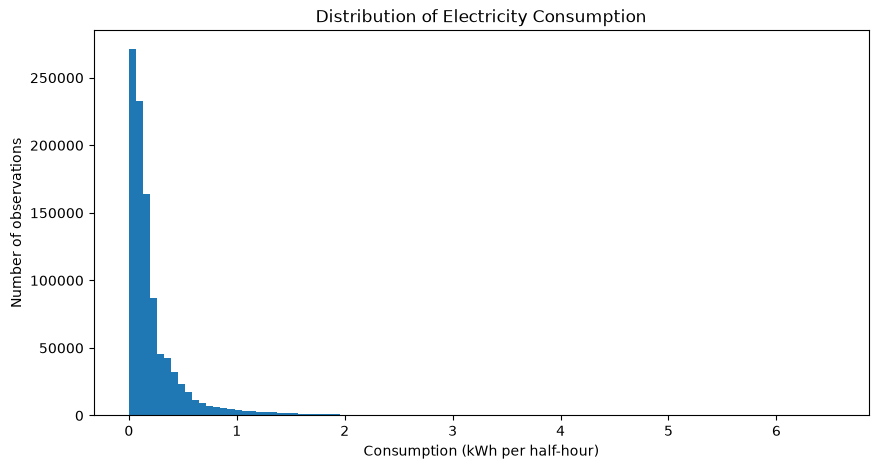

In [151]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df["consumption_kwh"], bins=100)
plt.xlabel("Consumption (kWh per half-hour)")
plt.ylabel("Number of observations")
plt.title("Distribution of Electricity Consumption")
plt.show()

# This is our first EDA visualization    EDA finding is:

# Electricity consumption is right-skewed: most half-hour observations are relatively low, while a smaller
#  number of observations have substantially higher consumption.

 ## Check daily observation coverage
 
 Before we use daily_demand for serious analysis, let's find out how many half-hour readings each day contains.

A complete day should normally have:

48 half-hour observations per household

In [152]:


daily_coverage = (
    df.groupby(df["DateTime"].dt.date)
      .size()
)
daily_coverage.head()



DateTime
2011-12-06     22
2011-12-07    492
2011-12-08    912
2011-12-09    912
2011-12-10    912
dtype: int64

In [153]:
daily_coverage.tail()

DateTime
2014-02-24    1248
2014-02-25    1248
2014-02-26    1248
2014-02-27    1248
2014-02-28      26
dtype: int64

In [154]:

daily_coverage.describe()

count     816.000000
mean     1224.611520
std       164.108104
min        22.000000
25%      1150.000000
50%      1248.000000
75%      1344.000000
max      1440.000000
dtype: float64

Let's make the deliberate
 ## EDA decision now,
  but first we need one precise check.

The 1248 result taught us that counting rows mixes together time coverage and household coverage. So for boundary detection, we should count unique half-hour timestamps per day.

In [155]:
daily_time_coverage = (
    df.groupby(df["DateTime"].dt.date)
    .nunique())

daily_coverage.head()

DateTime
2011-12-06     22
2011-12-07    492
2011-12-08    912
2011-12-09    912
2011-12-10    912
dtype: int64

The London data has timestamps that can differ within the same half-hour period, so multiple timestamps can belong to the same 30-minute interval.
## coverage calculation

Let's convert every timestamp into its corresponding 30-minute time bucket.

In [156]:
df["half_hour"] = df["DateTime"].dt.floor("30 min")

daily_slot_coverage = (
    df.groupby(df["DateTime"].dt.date)["half_hour"]
    .nunique())

daily_slot_coverage.head()

DateTime
2011-12-06    22
2011-12-07    48
2011-12-08    48
2011-12-09    48
2011-12-10    48
Name: half_hour, dtype: int64

In [157]:
daily_slot_coverage.tail(10)

DateTime
2014-02-19    48
2014-02-20    48
2014-02-21    48
2014-02-22    48
2014-02-23    48
2014-02-24    48
2014-02-25    48
2014-02-26    48
2014-02-27    48
2014-02-28     1
Name: half_hour, dtype: int64

In [158]:
incomplete_days = daily_slot_coverage[daily_slot_coverage < 48]
print("incomplete_days",len(incomplete_days))
print(incomplete_days)

incomplete_days 2
DateTime
2011-12-06    22
2014-02-28     1
Name: half_hour, dtype: int64


In [159]:
# Look at demand over time

# Now we want to move from individual observations to the actual time-series behavior
daily_demand = (
    df.set_index("DateTime")
      .resample("D")["consumption_kwh"]
      .sum()
)

daily_demand.head()


# is aggregating all half-hourly consumption into total daily electricity demand.

DateTime
2011-12-06      2.947
2011-12-07    143.160
2011-12-08    248.374
2011-12-09    216.327
2011-12-10    246.168
Freq: D, Name: consumption_kwh, dtype: float64

In [160]:
daily_demand.describe()

count    816.000000
mean     293.328649
std       89.227087
min        2.947000
25%      225.837250
50%      270.040000
75%      364.674250
max      511.710000
Name: consumption_kwh, dtype: float64

In [161]:
daily_demand.nsmallest(10)

DateTime
2011-12-06      2.947
2014-02-28     15.627
2012-07-21    142.655
2011-12-07    143.160
2012-08-08    152.409
2012-07-18    152.492
2012-08-26    156.559
2012-07-30    156.914
2012-08-27    158.182
2012-07-25    159.258
Name: consumption_kwh, dtype: float64

In [162]:
daily_demand.nlargest(10)

DateTime
2013-01-20    511.710000
2013-02-11    505.551999
2013-01-25    504.652001
2012-12-02    498.072001
2013-03-26    496.371000
2013-01-18    495.242000
2013-01-19    492.695001
2013-02-10    490.783001
2013-03-11    488.952000
2013-01-17    487.686999
Name: consumption_kwh, dtype: float64

## See how demand changes over time

Now we want to answer the most important EDA question:

### Does electricity demand show recurring patterns over time?

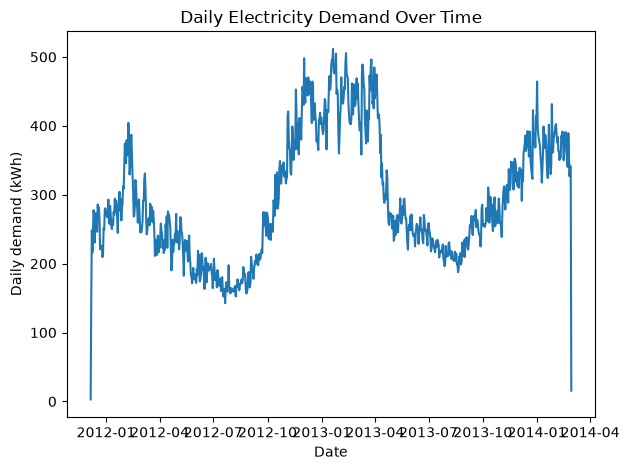

In [163]:
plt.Figure(figsize=(14,5))

plt.plot(daily_demand.index,daily_demand.values)
plt.xlabel("Date")
plt.ylabel("Daily demand (kWh)")
plt.title("Daily Electricity Demand Over Time")

plt.tight_layout()
plt.show()


This is important for GridWise because we're looking for trend, seasonality, peaks, unusual periods, and changing demand behavior—all of which influence how we'll design the forecasting model.

### EDA decision: incomplete boundary days

The processed dataset contains partial observations at the beginning and end
of the available time range. These produce artificially low daily totals.

For daily-demand EDA and later forecasting experiments, these boundary days
will be excluded from derived daily aggregates when appropriate.

The underlying processed Parquet dataset remains unchanged. No observations
are deleted during this EDA step.

In [164]:
daily_demand_eda=daily_demand.loc[
    "2011-12-07":"2014-02-27"
]
daily_demand_eda.describe()

count    814.000000
mean     294.026541
std       88.215634
min      142.655000
25%      226.008000
50%      270.280000
75%      364.832750
max      511.710000
Name: consumption_kwh, dtype: float64

### Weekly demand pattern

Now let's investigate:

Is electricity demand different on weekdays vs weekends?
If demand systematically changes by day of week, then day-of-week becomes a useful forecasting feature.

We're following:

EDA finding → feature hypothesis → later model feature

In [165]:
daily_demand_eda = daily_demand_eda.to_frame(name="demand_kwh")

daily_demand_eda["day_of_week"] = daily_demand_eda.index.day_name()

daily_demand_eda.groupby("day_of_week")["demand_kwh"].mean()


# This gives us another real feature hypothesis for GridWise.

day_of_week
Friday       287.290940
Monday       302.468741
Saturday     283.429241
Sunday       300.412862
Thursday     296.320077
Tuesday      295.107793
Wednesday    293.143966
Name: demand_kwh, dtype: float64

Day-of-week appears to influence demand, but the relationship is not strongly monotonic and should be evaluated as a forecasting feature rather than assumed to be important.

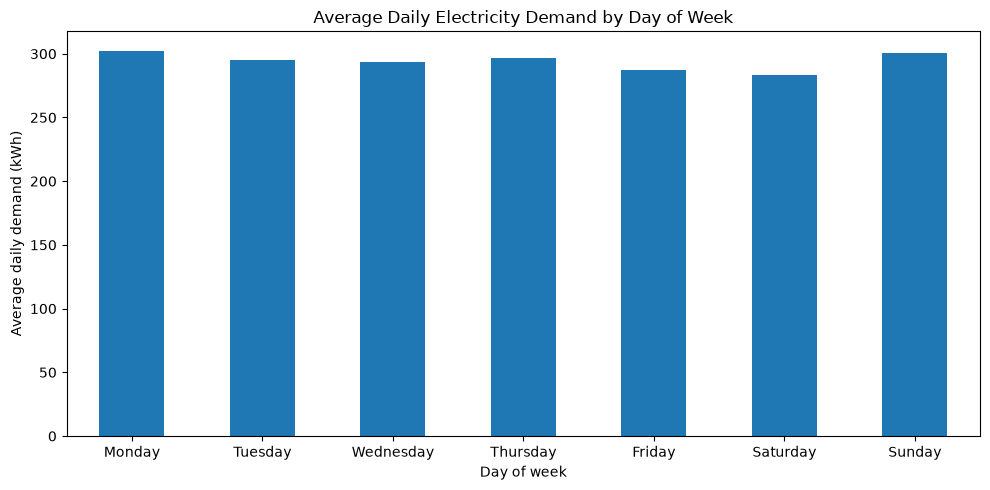

In [166]:
weekly_pattern = (
    daily_demand_eda
    .groupby("day_of_week")["demand_kwh"]
    .mean()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

weekly_pattern.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Day of week")
plt.ylabel("Average daily demand (kWh)")
plt.title("Average Daily Electricity Demand by Day of Week")
plt.xticks(rotation=0)
plt.tight_layout() #: Automatically adjusts the plot padding so that title, axis labels, and tick marks fit cleanly inside the figure boundary without being cut off or overlapping each other.
plt.show()

next EDA step should be monthly/seasonal behavior so we can determine whether electricity demand changes systematically across the year.

### Next task: Monthly seasonality

In [167]:
monthly_pattern = (
    daily_demand_eda
    .groupby(daily_demand_eda.index.month)["demand_kwh"]
    .mean())
monthly_pattern

DateTime
1     362.277430
2     377.383679
3     347.111597
4     290.257967
5     238.688758
6     218.689617
7     197.699597
8     190.789194
9     233.278667
10    282.251419
11    347.566883
12    352.327253
Name: demand_kwh, dtype: float64

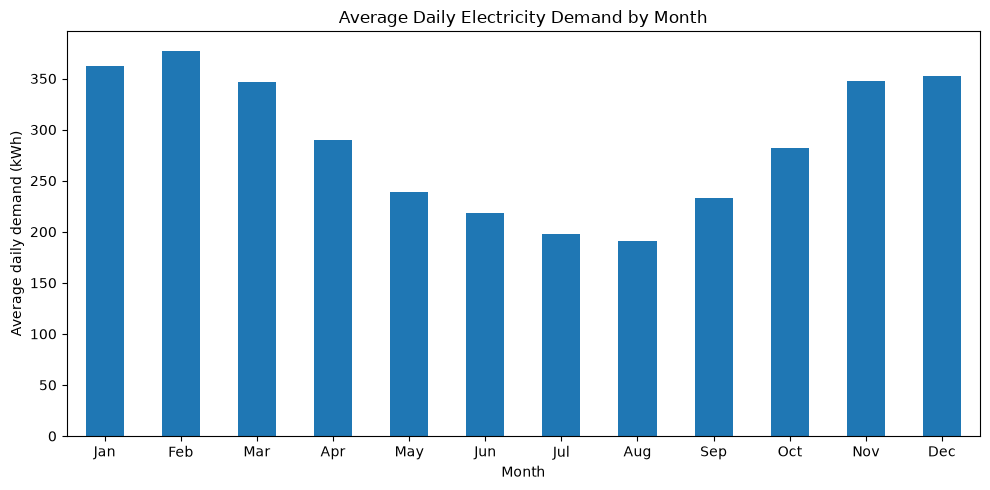

In [168]:
monthly_pattern.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Month")
plt.ylabel("Average daily demand (kWh)")
plt.title("Average Daily Electricity Demand by Month")
plt.xticks(range(12), [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
], rotation=0)

plt.tight_layout()
plt.show()

### Key Observation: Monthly Seasonality & Climate Context
- **Winter Peak (Nov–Feb):** Daily demand peaks during colder months (~350–377 kWh/day in Feb), driven by space heating, increased lighting, and longer indoor stays.
- **Summer Trough (Jun–Aug):** Demand reaches its lowest point (~190–218 kWh/day in Aug).
- **Domain Context:** This reflects a typical **winter-peaking load profile** common in northern European climates (London). Unlike summer-peaking regions (e.g., India, where air conditioning dominates summer load), domestic heating and lighting are the primary drivers of electricity spikes in this dataset.
- **Feature Engineering Takeaway:** `Month` or `Season` flags will serve as strong candidate features for capturing long-term seasonal patterns in our forecasting model.

In [169]:
# generate lag columns by applying .shift(n) to a target column in your DataFrame:

# df["demand_kwh"].shift(1): Creates a 1-step lag (yesterday's demand). It moves every value down by 1 row, leaving the top row as NaN.


daily_lag=daily_demand_eda.copy()

daily_lag["lag_1"]=daily_lag["demand_kwh"].shift(1)
daily_lag["lag_7"]=daily_lag["demand_kwh"].shift(7)


# .corr() calculates the Pearson correlation coefficient between numerical columns in a DataFrame.
# It measures the strength and direction of a linear relationship between two variables, outputting a value between -1.0 and +1.0:

# +1.0 (Strong Positive): As variable A goes up, variable B goes up proportionally. (e.g., today's energy demand strongly matches yesterday's).

# 0.0 (No Relationship): Knowing variable A gives you zero predictive clue about variable B.

# -1.0 (Strong Negative): As variable A goes up, variable B goes down proportionally.

daily_lag[["demand_kwh","lag_1","lag_7"]].corr()

,demand_kwh,lag_1,lag_7
demand_kwh,1.000000,0.967862,0.915838
lag_1,0.967862,1.000000,0.918606
lag_7,0.915838,0.918606,1.000000


Relationship	Correlation
Demand vs previous day (lag_1)	0.9679
Demand vs previous week (lag_7)	0.9158

### Lag Correlation

Daily electricity demand shows strong temporal persistence.

- Demand vs previous day (`lag_1`): correlation ≈ 0.968
- Demand vs previous week (`lag_7`): correlation ≈ 0.916

This indicates that recent historical demand contains substantial predictive
information. Both daily and weekly lag features are therefore strong
candidates for the forecasting model.

Correlation is used here for exploratory analysis only; the actual usefulness
of these features will be validated through chronological model evaluation.

In [170]:
for lag in [1, 2, 3, 7, 14, 30]:
    correlation = daily_lag["demand_kwh"].corr(
        daily_lag["demand_kwh"].shift(lag)
    )
    print(f"Lag {lag:>2}: {correlation:.4f}")

Lag  1: 0.9679
Lag  2: 0.9499
Lag  3: 0.9397
Lag  7: 0.9158
Lag 14: 0.8811
Lag 30: 0.7735


# EDA interpretation: Feature-engineering decision

The strongest relationship is with recent demand, and correlation gradually decreases as the lag becomes longer.

The key finding is:

Electricity demand has strong temporal persistence, with both short-term and weekly historical demand carrying substantial predictive information.

### Lag Correlation Analysis

Electricity demand exhibits strong temporal persistence.

| Lag | Correlation |
|---|---:|
| 1 day | 0.9679 |
| 2 days | 0.9499 |
| 3 days | 0.9397 |
| 7 days | 0.9158 |
| 14 days | 0.8811 |
| 30 days | 0.7735 |

Correlation decreases as the lag becomes longer, while remaining substantial
even at weekly and monthly horizons.

This supports using recent historical demand as a forecasting signal.
The initial candidate lag features are `lag_1`, `lag_2`, `lag_3`, and `lag_7`.
Longer lags will only be added if model evaluation demonstrates that they
provide meaningful additional predictive value.

# INTRA Day pattern:
At what times of day is electricity demand typically highest and lowest?

In [171]:
df["hour"] = df["DateTime"].dt.hour

hourly_pattern = (
    df.groupby("hour")["consumption_kwh"]
      .mean()
)

hourly_pattern


hour
0     0.350818
1     0.322319
2     0.266656
3     0.224086
4     0.189768
5     0.179395
6     0.188437
7     0.179425
8     0.203655
9     0.222750
10    0.227093
11    0.235603
12    0.241874
13    0.238646
14    0.230154
15    0.218509
16    0.221438
17    0.252210
18    0.280706
19    0.288996
20    0.282805
21    0.265482
22    0.240516
23    0.197155
Name: consumption_kwh, dtype: float64

### Intraday Demand Pattern

Average electricity consumption varies systematically throughout the day.
Demand is relatively low during the early morning hours and increases toward
the evening, reaching its highest observed average around 19:00.

This indicates that time-of-day is an important candidate predictor for
forecasting electricity demand. The `hour` feature will therefore be tested
during feature engineering and model evaluation.

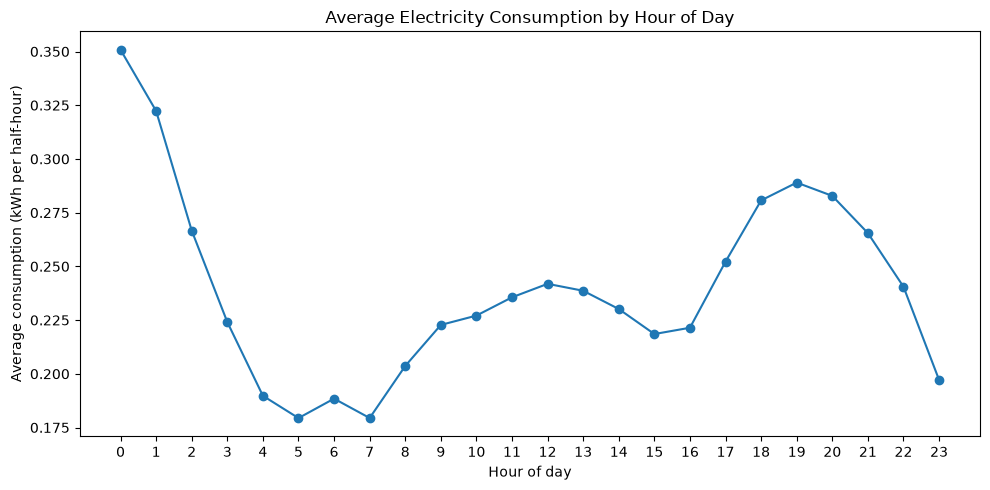

In [173]:
hourly_pattern.plot(
    kind="line",
    figsize=(10,5),
    marker="o"
)
plt.xlabel("Hour of day")
plt.ylabel("Average consumption (kWh per half-hour)")
plt.title("Average Electricity Consumption by Hour of Day")
plt.xticks(range(24))
plt.tight_layout()
plt.show()


### Intraday Demand Pattern

Average electricity consumption varies substantially by hour of day.

Demand is relatively high around midnight, declines during the early morning,
and reaches its lowest levels around the early morning hours. Consumption then
increases through the day, with a pronounced secondary peak during the evening
around 18:00–20:00 before declining again later at night.

This indicates that time-of-day is an important candidate predictor for
electricity-demand forecasting. The `hour` feature will therefore be tested
during feature engineering and model evaluation.

### final EDA check: relationship between demand and its recent history visually,

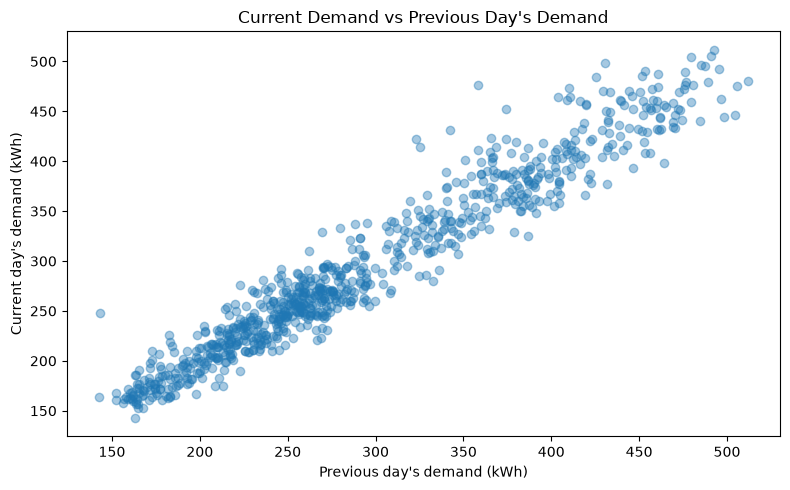

In [178]:
plt.figure(figsize=(8,5))

plt.scatter(
    daily_lag["lag_1"],
    daily_lag["demand_kwh"],
     alpha=0.4
)
plt.xlabel("Previous day's demand (kWh)")
plt.ylabel("Current day's demand (kWh)")
plt.title("Current Demand vs Previous Day's Demand")

plt.tight_layout()
plt.show()

The transparency actually helps us see that most observations cluster tightly around the upward relationship, while a smaller number of observations sit farther away.

That's exactly what we wanted from this sanity-check plot. ✅

plot confirms the previous finding: current daily demand has a very strong positive relationship with previous-day demand.